Step 1/20 | Acc: 0.3339
Step 2/20 | Acc: 0.5826
Step 3/20 | Acc: 0.7744
Step 4/20 | Acc: 0.8540
Step 5/20 | Acc: 0.9100
Step 6/20 | Acc: 0.9353
Step 7/20 | Acc: 0.9478
Step 8/20 | Acc: 0.9522
Step 9/20 | Acc: 0.9544
Step 10/20 | Acc: 0.9548
Step 11/20 | Acc: 0.9561
Step 12/20 | Acc: 0.9572
Step 13/20 | Acc: 0.9574
Step 14/20 | Acc: 0.9574
Step 15/20 | Acc: 0.9581
Step 16/20 | Acc: 0.9588
Step 17/20 | Acc: 0.9594
Step 18/20 | Acc: 0.9593
Step 19/20 | Acc: 0.9613
Step 20/20 | Acc: 0.9675
Mean acquisition accuracy: 0.8895950000000001


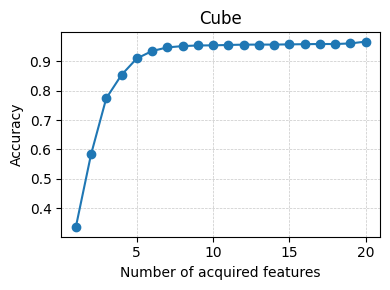

Step 1/20 | Acc: 0.3339 | 평균 GT feature 개수: 0.375
Step 2/20 | Acc: 0.5826 | 평균 GT feature 개수: 0.844
Step 3/20 | Acc: 0.7744 | 평균 GT feature 개수: 1.151
Step 4/20 | Acc: 0.8540 | 평균 GT feature 개수: 1.340
Step 5/20 | Acc: 0.9100 | 평균 GT feature 개수: 1.464
Step 6/20 | Acc: 0.9353 | 평균 GT feature 개수: 1.534
Step 7/20 | Acc: 0.9478 | 평균 GT feature 개수: 1.589
Step 8/20 | Acc: 0.9522 | 평균 GT feature 개수: 1.639
Step 9/20 | Acc: 0.9544 | 평균 GT feature 개수: 1.687
Step 10/20 | Acc: 0.9548 | 평균 GT feature 개수: 1.731
Step 11/20 | Acc: 0.9561 | 평균 GT feature 개수: 1.781
Step 12/20 | Acc: 0.9572 | 평균 GT feature 개수: 1.835
Step 13/20 | Acc: 0.9574 | 평균 GT feature 개수: 1.885
Step 14/20 | Acc: 0.9574 | 평균 GT feature 개수: 1.934
Step 15/20 | Acc: 0.9581 | 평균 GT feature 개수: 1.976
Step 16/20 | Acc: 0.9588 | 평균 GT feature 개수: 2.010
Step 17/20 | Acc: 0.9594 | 평균 GT feature 개수: 2.044
Step 18/20 | Acc: 0.9593 | 평균 GT feature 개수: 2.084
Step 19/20 | Acc: 0.9613 | 평균 GT feature 개수: 2.386
Step 20/20 | Acc: 0.9675 | 평균 GT feature

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
from train_utils import (
    run_feature_acquisition,
    run_feature_acquisition_cube
)

from joint_model_신버전 import (
    StudentModel,
)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # blackwell

X_train = torch.load(f"../data/cube/X_train_cdf.pt").float()
y_train = torch.load(f"../data/cube/y_train.pt").long()

X_val   = torch.load(f"../data/cube/X_val_cdf.pt").float()
y_val   = torch.load(f"../data/cube/y_val.pt").long()

X_test = torch.load(f"../data/cube/X_test_cdf.pt").float()
y_test = torch.load(f"../data/cube/y_test.pt").long()

num_features = 20
num_classes = 8

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 256

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

z_dim          = 16   # per-feature latent dim
enc_hidden_dim = 16   # JointEncoder 내부 attention token dim
dec_hidden_dim = 64  # predictor MLP hidden dim
dec_num_hidden = 2    # predictor MLP hidden layer 개수
num_heads      = 16 # attention head의 개수

student = StudentModel(
    num_features=num_features,
    z_dim=z_dim,
    enc_hidden_dim=enc_hidden_dim,
    num_heads=num_heads,
    dec_hidden_dim=dec_hidden_dim,
    dec_num_hidden=dec_num_hidden,
    out_dim=num_classes,
).to(device)

ckpt = torch.load("../checkpoints/student_cube.pt", map_location=device)
student.load_state_dict(ckpt) 

student.eval()
result = []

accs = run_feature_acquisition(
    predictor=student,
    X_test=X_test,
    y_test=y_test,
    alpha=15.0,
    gamma=0.0
)

result.append(accs)

mean_acc = np.mean(accs)
print("Mean acquisition accuracy:", mean_acc)

accs = np.array(accs)  # (K,) 라고 가정
K = np.arange(1, len(accs) + 1)  # K = 1,2,...,num_features

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(K, accs, marker='o')  # 기본 색/스타일 사용
ax.set_xlabel("Number of acquired features")
ax.set_ylabel("Accuracy")
ax.set_title("Cube")  # 캡션 제목

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

accs, true_feat_counts_per_step = run_feature_acquisition_cube(
    predictor=student,
    X_test=X_test,
    y_test=y_test,
    alpha=15.0,
    gamma=0.0,
)

mean_acc = np.mean(accs)
print("Mean acquisition accuracy:", mean_acc)

# 예시: step 3에서 관련 feature 몇 개 골랐는지 분포 보기
t_step = 18
selected_counts_t3 = true_feat_counts_per_step[t_step - 1]  # (N,)
vals, cnts = np.unique(selected_counts_t3, return_counts=True)
print(f"\n[Step {t_step}] distribution of #true-feats selected:")
for v, c in zip(vals, cnts):
    print(f"  {v}개: {c} / {len(selected_counts_t3)} ({c / len(selected_counts_t3):.3f})")


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
from train_utils import (
    run_feature_acquisition
)

from joint_model_신버전 import (
    StudentModel,
)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # blackwell

X_train = torch.load(f"../data/bank_marketing/X_train_cdf.pt").float()
y_train = torch.load(f"../data/bank_marketing/y_train.pt").long()

X_val   = torch.load(f"../data/bank_marketing/X_val_cdf.pt").float()
y_val   = torch.load(f"../data/bank_marketing/y_val.pt").long()

X_test = torch.load(f"../data/bank_marketing/X_test_cdf.pt").float()
y_test = torch.load(f"../data/bank_marketing/y_test.pt").long()

num_features = 15
num_classes = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 256

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

z_dim          = 8   # per-feature latent dim
enc_hidden_dim = 16   # JointEncoder 내부 attention token dim
dec_hidden_dim = 64 # predictor MLP hidden dim
dec_num_hidden = 2    # predictor MLP hidden layer 개수
num_heads      = 4 # attention head의 개수

student = StudentModel(
    num_features=num_features,
    z_dim=z_dim,
    enc_hidden_dim=enc_hidden_dim,
    num_heads=num_heads,
    dec_hidden_dim=dec_hidden_dim,
    dec_num_hidden=dec_num_hidden,
    out_dim=num_classes,
).to(device)

ckpt = torch.load("../checkpoints/student_bank_marketing.pt", map_location=device)
student.load_state_dict(ckpt) 

student.eval()
result = []

accs = run_feature_acquisition(
    predictor=student,
    X_test=X_test,
    y_test=y_test,
    alpha=1.0,
    gamma=0.7
)

result.append(accs)

mean_acc = np.mean(accs)
print("Mean acquisition accuracy:", mean_acc)

accs = np.array(accs)  # (K,) 라고 가정
K = np.arange(1, len(accs) + 1)  # K = 1,2,...,num_features

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(K, accs, marker='o')  # 기본 색/스타일 사용
ax.set_xlabel("Number of acquired features")
ax.set_ylabel("AUROC")
ax.set_title("Bank Marketing")  # 캡션 제목

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

RuntimeError: Error(s) in loading state_dict for StudentModel:
	Missing key(s) in state_dict: "predictor.attention.in_proj_weight", "predictor.attention.in_proj_bias", "predictor.attention.out_proj.weight", "predictor.attention.out_proj.bias", "predictor.ln1.weight", "predictor.ln1.bias", "predictor.ffn.0.weight", "predictor.ffn.0.bias", "predictor.ffn.2.weight", "predictor.ffn.2.bias", "predictor.ln2.weight", "predictor.ln2.bias", "predictor.mlp.network.0.weight", "predictor.mlp.network.0.bias", "predictor.mlp.network.2.weight", "predictor.mlp.network.2.bias", "predictor.mlp.network.2.running_mean", "predictor.mlp.network.2.running_var", "predictor.mlp.network.3.weight", "predictor.mlp.network.3.bias", "predictor.mlp.network.5.weight", "predictor.mlp.network.5.bias", "predictor.mlp.network.5.running_mean", "predictor.mlp.network.5.running_var", "predictor.mlp.network.6.weight", "predictor.mlp.network.6.bias". 
	Unexpected key(s) in state_dict: "predictor.network.0.weight", "predictor.

Step 1/8 | Acc: 0.4486
Step 2/8 | Acc: 0.5349
Step 3/8 | Acc: 0.6328
Step 4/8 | Acc: 0.6720
Step 5/8 | Acc: 0.6885
Step 6/8 | Acc: 0.6982
Step 7/8 | Acc: 0.7093
Step 8/8 | Acc: 0.7263
Mean acquisition accuracy: 0.6388081395348837


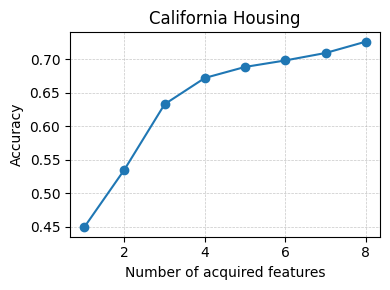

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
from train_utils import (
    run_feature_acquisition
)

from joint_model_신버전 import (
    StudentModel,
)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # blackwell

X_train = torch.load(f"../data/california_housing/X_train_cdf.pt").float()
y_train = torch.load(f"../data/california_housing/y_train.pt").long()

X_val   = torch.load(f"../data/california_housing/X_val_cdf.pt").float()
y_val   = torch.load(f"../data/california_housing/y_val.pt").long()

X_test = torch.load(f"../data/california_housing/X_test_cdf.pt").float()
y_test = torch.load(f"../data/california_housing/y_test.pt").long()

num_features = 8
num_classes = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 256

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

z_dim          = 16   # per-feature latent dim
enc_hidden_dim = 64   # JointEncoder 내부 attention token dim
dec_hidden_dim = 256  # predictor MLP hidden dim
dec_num_hidden = 2    # predictor MLP hidden layer 개수
num_heads      = 8 # attention head의 개수

student = StudentModel(
    num_features=num_features,
    z_dim=z_dim,
    enc_hidden_dim=enc_hidden_dim,
    num_heads=num_heads,
    dec_hidden_dim=dec_hidden_dim,
    dec_num_hidden=dec_num_hidden,
    out_dim=num_classes,
).to(device)

ckpt = torch.load("../checkpoints/student_california_housing.pt", map_location=device)
student.load_state_dict(ckpt) 

student.eval()
result = []

accs = run_feature_acquisition(
    predictor=student,
    X_test=X_test,
    y_test=y_test,
    alpha=1.0,
    gamma=0.6
)

result.append(accs)

mean_acc = np.mean(accs)
print("Mean acquisition accuracy:", mean_acc)

accs = np.array(accs)  # (K,) 라고 가정
K = np.arange(1, len(accs) + 1)  # K = 1,2,...,num_features

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(K, accs, marker='o')  # 기본 색/스타일 사용
ax.set_xlabel("Number of acquired features")
ax.set_ylabel("Accuracy")
ax.set_title("California Housing")  # 캡션 제목

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

Step 1/20 | Acc: 0.7665
Step 2/20 | Acc: 0.8114
Step 3/20 | Acc: 0.8387
Step 4/20 | Acc: 0.8555
Step 5/20 | Acc: 0.8686
Step 6/20 | Acc: 0.8753
Step 7/20 | Acc: 0.8829
Step 8/20 | Acc: 0.8888
Step 9/20 | Acc: 0.8952
Step 10/20 | Acc: 0.8983
Step 11/20 | Acc: 0.9019
Step 12/20 | Acc: 0.9048
Step 13/20 | Acc: 0.9077
Step 14/20 | Acc: 0.9099
Step 15/20 | Acc: 0.9137
Step 16/20 | Acc: 0.9169
Step 17/20 | Acc: 0.9165
Step 18/20 | Acc: 0.9180
Step 19/20 | Acc: 0.9203
Step 20/20 | Acc: 0.9210
Mean acquisition accuracy: 0.885595


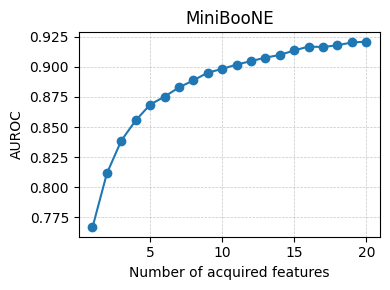

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
from train_utils import (
    run_feature_acquisition
)

from joint_model_신버전 import (
    StudentModel,
)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # blackwell

X_train = torch.load(f"../data/miniboone/X_train_cdf.pt").float()
y_train = torch.load(f"../data/miniboone/y_train.pt").long()

X_val   = torch.load(f"../data/miniboone/X_val_cdf.pt").float()
y_val   = torch.load(f"../data/miniboone/y_val.pt").long()

X_test = torch.load(f"../data/miniboone/X_test_cdf.pt").float()
y_test = torch.load(f"../data/miniboone/y_test.pt").long()

num_features = 20
num_classes = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 256

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

z_dim          = 64   # per-feature latent dim
enc_hidden_dim = 8   # JointEncoder 내부 attention token dim
dec_hidden_dim = 256 # predictor MLP hidden dim
dec_num_hidden = 2    # predictor MLP hidden layer 개수
num_heads      = 8 # attention head의 개수

student = StudentModel(
    num_features=num_features,
    z_dim=z_dim,
    enc_hidden_dim=enc_hidden_dim,
    num_heads=num_heads,
    dec_hidden_dim=dec_hidden_dim,
    dec_num_hidden=dec_num_hidden,
    out_dim=num_classes,
).to(device)

ckpt = torch.load("../checkpoints/student_miniboone.pt", map_location=device)
student.load_state_dict(ckpt) 

student.eval()
result = []

accs = run_feature_acquisition(
    predictor=student,
    X_test=X_test,
    y_test=y_test,
    alpha=1.0,
    gamma=0.0
)

result.append(accs)

mean_acc = np.mean(accs)
print("Mean acquisition accuracy:", mean_acc)

accs = np.array(accs)  # (K,) 라고 가정
K = np.arange(1, len(accs) + 1)  # K = 1,2,...,num_features

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(K, accs, marker='o')  # 기본 색/스타일 사용
ax.set_xlabel("Number of acquired features")
ax.set_ylabel("AUROC")
ax.set_title("MiniBooNE")  # 캡션 제목

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

Step 1/20 | Acc: 0.1935
Step 2/20 | Acc: 0.2695
Step 3/20 | Acc: 0.3508
Step 4/20 | Acc: 0.4254
Step 5/20 | Acc: 0.4917
Step 6/20 | Acc: 0.5477
Step 7/20 | Acc: 0.5974
Step 8/20 | Acc: 0.6426
Step 9/20 | Acc: 0.6894
Step 10/20 | Acc: 0.7229
Step 11/20 | Acc: 0.7536
Step 12/20 | Acc: 0.7787
Step 13/20 | Acc: 0.8052
Step 14/20 | Acc: 0.8221
Step 15/20 | Acc: 0.8383
Step 16/20 | Acc: 0.8536
Step 17/20 | Acc: 0.8662
Step 18/20 | Acc: 0.8786
Step 19/20 | Acc: 0.8919
Step 20/20 | Acc: 0.9007
Mean acquisition accuracy: 0.66599


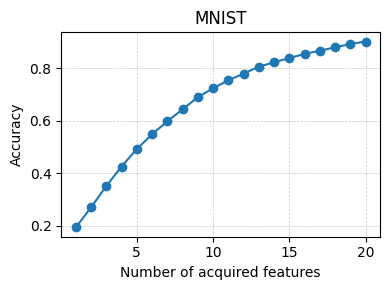

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
from train_utils import (
    run_feature_acquisition
)

from joint_model_신버전 import (
    StudentModel,
)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # blackwell

X_train = torch.load(f"../data/mnist/X_train_cdf.pt").float()
y_train = torch.load(f"../data/mnist/y_train.pt").long()

X_val   = torch.load(f"../data/mnist/X_val_cdf.pt").float()
y_val   = torch.load(f"../data/mnist/y_val.pt").long()

X_test = torch.load(f"../data/mnist/X_test_cdf.pt").float()
y_test = torch.load(f"../data/mnist/y_test.pt").long()

num_features = 20
num_classes = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 256

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

z_dim          = 16   # per-feature latent dim
enc_hidden_dim = 32   # JointEncoder 내부 attention token dim
dec_hidden_dim = 256 # predictor MLP hidden dim
dec_num_hidden = 2    # predictor MLP hidden layer 개수
num_heads      = 8 # attention head의 개수

student = StudentModel(
    num_features=num_features,
    z_dim=z_dim,
    enc_hidden_dim=enc_hidden_dim,
    num_heads=num_heads,
    dec_hidden_dim=dec_hidden_dim,
    dec_num_hidden=dec_num_hidden,
    out_dim=num_classes,
).to(device)

ckpt = torch.load("../checkpoints/student_mnist.pt", map_location=device)
student.load_state_dict(ckpt) 

student.eval()
result = []

accs = run_feature_acquisition(
    predictor=student,
    X_test=X_test,
    y_test=y_test,
    alpha=1.0,
    gamma=0.6
)

result.append(accs)

mean_acc = np.mean(accs)
print("Mean acquisition accuracy:", mean_acc)

accs = np.array(accs)  # (K,) 라고 가정
K = np.arange(1, len(accs) + 1)  # K = 1,2,...,num_features

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(K, accs, marker='o')  # 기본 색/스타일 사용
ax.set_xlabel("Number of acquired features")
ax.set_ylabel("Accuracy")
ax.set_title("MNIST")  # 캡션 제목

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

Step 1/20 | Acc: 0.2183
Step 2/20 | Acc: 0.3429
Step 3/20 | Acc: 0.4464
Step 4/20 | Acc: 0.5338
Step 5/20 | Acc: 0.5846
Step 6/20 | Acc: 0.6283
Step 7/20 | Acc: 0.6641
Step 8/20 | Acc: 0.6881
Step 9/20 | Acc: 0.7090
Step 10/20 | Acc: 0.7288
Step 11/20 | Acc: 0.7380
Step 12/20 | Acc: 0.7480
Step 13/20 | Acc: 0.7594
Step 14/20 | Acc: 0.7662
Step 15/20 | Acc: 0.7753
Step 16/20 | Acc: 0.7789
Step 17/20 | Acc: 0.7835
Step 18/20 | Acc: 0.7887
Step 19/20 | Acc: 0.7926
Step 20/20 | Acc: 0.7984
Mean acquisition accuracy: 0.663665


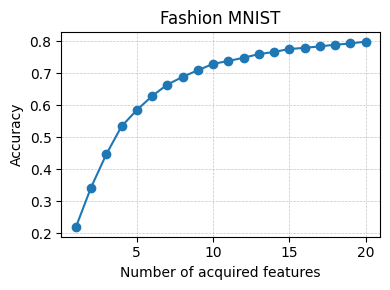

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
from train_utils import (
    run_feature_acquisition
)

from joint_model_신버전 import (
    StudentModel,
)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # blackwell

X_train = torch.load(f"../data/fashion_mnist/X_train_cdf.pt").float()
y_train = torch.load(f"../data/fashion_mnist/y_train.pt").long()

X_val   = torch.load(f"../data/fashion_mnist/X_val_cdf.pt").float()
y_val   = torch.load(f"../data/fashion_mnist/y_val.pt").long()

X_test = torch.load(f"../data/fashion_mnist/X_test_cdf.pt").float()
y_test = torch.load(f"../data/fashion_mnist/y_test.pt").long()

num_features = 20
num_classes = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 256

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

z_dim          = 16   # per-feature latent dim
enc_hidden_dim = 32   # JointEncoder 내부 attention token dim
dec_hidden_dim = 256 # predictor MLP hidden dim
dec_num_hidden = 2    # predictor MLP hidden layer 개수
num_heads      = 8 # attention head의 개수

student = StudentModel(
    num_features=num_features,
    z_dim=z_dim,
    enc_hidden_dim=enc_hidden_dim,
    num_heads=num_heads,
    dec_hidden_dim=dec_hidden_dim,
    dec_num_hidden=dec_num_hidden,
    out_dim=num_classes,
).to(device)

ckpt = torch.load("../checkpoints/student_fashion_mnist.pt", map_location=device)
student.load_state_dict(ckpt) 

student.eval()
result = []

accs = run_feature_acquisition(
    predictor=student,
    X_test=X_test,
    y_test=y_test,
    alpha=1.0,
    gamma=0.1
)

result.append(accs)

mean_acc = np.mean(accs)
print("Mean acquisition accuracy:", mean_acc)

accs = np.array(accs)  # (K,) 라고 가정
K = np.arange(1, len(accs) + 1)  # K = 1,2,...,num_features

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(K, accs, marker='o')  # 기본 색/스타일 사용
ax.set_xlabel("Number of acquired features")
ax.set_ylabel("Accuracy")
ax.set_title("Fashion MNIST")  # 캡션 제목

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

Step 1/12 | ACC: 0.4712
Step 2/12 | ACC: 0.4869
Step 3/12 | ACC: 0.5131
Step 4/12 | ACC: 0.5445
Step 5/12 | ACC: 0.5602
Step 6/12 | ACC: 0.5812
Step 7/12 | ACC: 0.6021
Step 8/12 | ACC: 0.5969
Step 9/12 | ACC: 0.6073
Step 10/12 | ACC: 0.6597
Step 11/12 | ACC: 0.6806
Step 12/12 | ACC: 0.6649
Mean acquisition accuracy: 0.5807155322862129


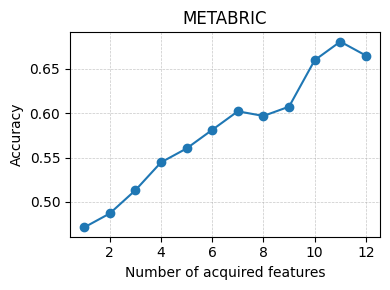

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
from train_utils import (
    run_feature_acquisition
)

from joint_model import (
    StudentModel,
)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # blackwell

X_train = torch.load(f"../data/metabric/X_train_cdf.pt").float()
y_train = torch.load(f"../data/metabric/y_train.pt").long()

X_val   = torch.load(f"../data/metabric/X_val_cdf.pt").float()
y_val   = torch.load(f"../data/metabric/y_val.pt").long()

X_test = torch.load(f"../data/metabric/X_test_cdf.pt").float()
y_test = torch.load(f"../data/metabric/y_test.pt").long()

num_features = 12
num_classes = 6

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 256

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

z_dim          = 64   # per-feature latent dim
enc_hidden_dim = 8   # JointEncoder 내부 attention token dim
dec_hidden_dim = 256 # predictor MLP hidden dim
dec_num_hidden = 2    # predictor MLP hidden layer 개수
num_heads      = 8 # attention head의 개수

student = StudentModel(
    num_features=num_features,
    z_dim=z_dim,
    enc_hidden_dim=enc_hidden_dim,
    num_heads=num_heads,
    dec_hidden_dim=dec_hidden_dim,
    dec_num_hidden=dec_num_hidden,
    out_dim=num_classes,
).to(device)

ckpt = torch.load("../checkpoints/student_metabric.pt", map_location=device)
student.load_state_dict(ckpt) 

student.eval()
result = []

SEED = 9750
np.random.seed(SEED)
torch.manual_seed(SEED)

accs = run_feature_acquisition(
    predictor=student,
    X_test=X_test,
    y_test=y_test,
    alpha=1.0,
    gamma=0.0
)

result.append(accs)

mean_acc = np.mean(accs)
print("Mean acquisition accuracy:", mean_acc)

accs = np.array(accs)  # (K,) 라고 가정
K = np.arange(1, len(accs) + 1)  # K = 1,2,...,num_features

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(K, accs, marker='o')  # 기본 색/스타일 사용
ax.set_xlabel("Number of acquired features")
ax.set_ylabel("Accuracy")
ax.set_title("METABRIC")  # 캡션 제목

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()